# Q2 — Finetune VGG19 on the 15-class dataset

This notebook finetunes a pretrained VGG19. It includes utilities to partially unfreeze layers and compute per-class precision & recall.

In [9]:
# Setup for Colab and local environments
import os, sys
from pathlib import Path

# Detect if running in Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print('Running in Google Colab')
    # Clone repo to get dataset
    os.system('git clone https://github.com/nelsunnel/LLMs-and-GenAI-Assignment.git /content/project')
    os.chdir('/content/project')
    # Install requirements
    os.system('pip install -q -r requirements.txt')
    PROJECT_ROOT = Path('/content/project')
else:
    print('Running locally')
    PROJECT_ROOT = Path('.')

print('Project root:', PROJECT_ROOT)

Running locally
Project root: .


In [18]:
from pathlib import Path
import re, time
import platform
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import precision_recall_fscore_support
from tqdm.notebook import tqdm

DATA_ROOT = PROJECT_ROOT / 'Datasets' / 'dataset'
if not DATA_ROOT.exists():
    raise RuntimeError('Dataset not found — adjust DATA_ROOT')
CLASSES = sorted([p.name for p in DATA_ROOT.iterdir() if p.is_dir()])
NUM_CLASSES = len(CLASSES)

def build_splits(root, classes):
    import re
    train, test = [], []
    num_re = re.compile(r'(\d+)')
    for idx, c in enumerate(classes):
        p = Path(root)/c
        imgs = sorted([x for x in p.iterdir() if x.suffix.lower() in ['.jpg','.png','.jpeg']])
        for im in imgs:
            m = num_re.search(im.stem)
            if m and 1 <= int(m.group(1)) <= 40:
                train.append((str(im), idx))
            else:
                test.append((str(im), idx))
    return train, test

train_items, test_items = build_splits(DATA_ROOT, CLASSES)
print(len(train_items), len(test_items))

IMG_SIZE = 224
train_tf = transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
test_tf = transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

class SimpleImageDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        p, label = self.items[idx]
        img = Image.open(p).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label

train_ds = SimpleImageDataset(train_items, transform=train_tf)
test_ds = SimpleImageDataset(test_items, transform=test_tf)

# Windows multiprocessing in notebooks is fragile; use single-worker to avoid crashes.
if IN_COLAB:
    num_workers = 2
elif platform.system() == 'Windows':
    num_workers = 0
else:
    num_workers = 4

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=num_workers)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=num_workers)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device', device)

600 205
Device cuda


In [11]:
# VGG19 model setup
def get_vgg19(num_classes, pretrained=True):
    model = models.vgg19(pretrained=pretrained)
    # Replace the final classifier layer
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    return model

In [12]:
# Utility to freeze/unfreeze layers
def set_parameter_requires_grad(model, unfreeze_from_layer=0):
    # Freeze all feature layers first
    for i, param in enumerate(model.features.parameters()):
        param.requires_grad = False
    
    # Unfreeze from the specified layer index onwards
    if unfreeze_from_layer > 0:
        for i, param in enumerate(model.features.parameters()):
            if i >= unfreeze_from_layer:
                param.requires_grad = True
    
    # The classifier is always trainable
    for param in model.classifier.parameters():
        param.requires_grad = True

In [13]:
# Training loop for finetuning
def train(model, loader, criterion, optimizer, epochs=3):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        pbar = tqdm(loader, desc=f'Epoch {epoch+1}/{epochs}')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            pbar.set_postfix({'loss': running_loss / (pbar.n + 1)})
    print('Finished Training')

In [14]:
# Evaluation and reporting
def evaluate_and_report(model, loader, classes):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Evaluating'):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels, all_preds, average=None, labels=list(range(len(classes)))
    )
    
    report_df = pd.DataFrame({
        'class': classes,
        'precision': precision,
        'recall': recall,
        'f1-score': f1,
        'support': support
    })
    
    print('\nResults:')
    print(report_df)
    return report_df

In [19]:
# --- Experiment: Finetune only the classifier head ---
print('--- Running: Finetune Classifier Only ---')
vgg_classifier_only = get_vgg19(NUM_CLASSES).to(device)

# Freeze all feature layers, only classifier is trainable
set_parameter_requires_grad(vgg_classifier_only, unfreeze_from_layer=-1) # -1 means freeze all feature layers

# Optimizer for only the trainable parameters
params_to_update = [p for p in vgg_classifier_only.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params_to_update, lr=1e-4, momentum=0.9)
criterion = nn.CrossEntropyLoss()

train(vgg_classifier_only, train_loader, criterion, optimizer, epochs=5)
classifier_results = evaluate_and_report(vgg_classifier_only, test_loader, CLASSES)

--- Running: Finetune Classifier Only ---


Epoch 1/5:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 2/5:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 3/5:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 4/5:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 5/5:   0%|          | 0/19 [00:00<?, ?it/s]

Finished Training


Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]


Results:
             class  precision    recall  f1-score  support
0        accordion   0.789474  1.000000  0.882353       15
1             bass   1.000000  1.000000  1.000000       14
2           camera   1.000000  1.000000  1.000000       10
3        crocodile   0.545455  0.600000  0.571429       10
4   crocodile_head   0.666667  0.909091  0.769231       11
5              cup   1.000000  1.000000  1.000000       17
6      dollar_bill   1.000000  1.000000  1.000000       12
7              emu   1.000000  1.000000  1.000000       13
8       gramophone   1.000000  1.000000  1.000000       11
9         hedgehog   1.000000  0.928571  0.962963       14
10        nautilus   0.937500  1.000000  0.967742       15
11           pizza   0.928571  1.000000  0.962963       13
12         pyramid   1.000000  0.705882  0.827586       17
13       sea_horse   1.000000  0.588235  0.740741       17
14   windsor_chair   0.888889  1.000000  0.941176       16


In [20]:
# --- Experiment: Finetune from last conv block ---
print('\n--- Running: Finetune from Last Conv Block ---')
vgg_last_block = get_vgg19(NUM_CLASSES).to(device)

# VGG19 features has 37 layers. Last block starts around layer 24.
set_parameter_requires_grad(vgg_last_block, unfreeze_from_layer=24)

params_to_update = [p for p in vgg_last_block.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params_to_update, lr=1e-4, momentum=0.9)
criterion = nn.CrossEntropyLoss()

train(vgg_last_block, train_loader, criterion, optimizer, epochs=5)
last_block_results = evaluate_and_report(vgg_last_block, test_loader, CLASSES)


--- Running: Finetune from Last Conv Block ---


c:\Users\undha\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\undha\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 2/5:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 3/5:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 4/5:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 5/5:   0%|          | 0/19 [00:00<?, ?it/s]

Finished Training


Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]


Results:
             class  precision    recall  f1-score  support
0        accordion   0.937500  1.000000  0.967742       15
1             bass   0.823529  1.000000  0.903226       14
2           camera   1.000000  1.000000  1.000000       10
3        crocodile   0.857143  0.600000  0.705882       10
4   crocodile_head   0.600000  0.818182  0.692308       11
5              cup   1.000000  1.000000  1.000000       17
6      dollar_bill   0.923077  1.000000  0.960000       12
7              emu   1.000000  1.000000  1.000000       13
8       gramophone   1.000000  0.909091  0.952381       11
9         hedgehog   1.000000  1.000000  1.000000       14
10        nautilus   1.000000  1.000000  1.000000       15
11           pizza   1.000000  1.000000  1.000000       13
12         pyramid   1.000000  0.823529  0.903226       17
13       sea_horse   1.000000  0.764706  0.866667       17
14   windsor_chair   0.888889  1.000000  0.941176       16


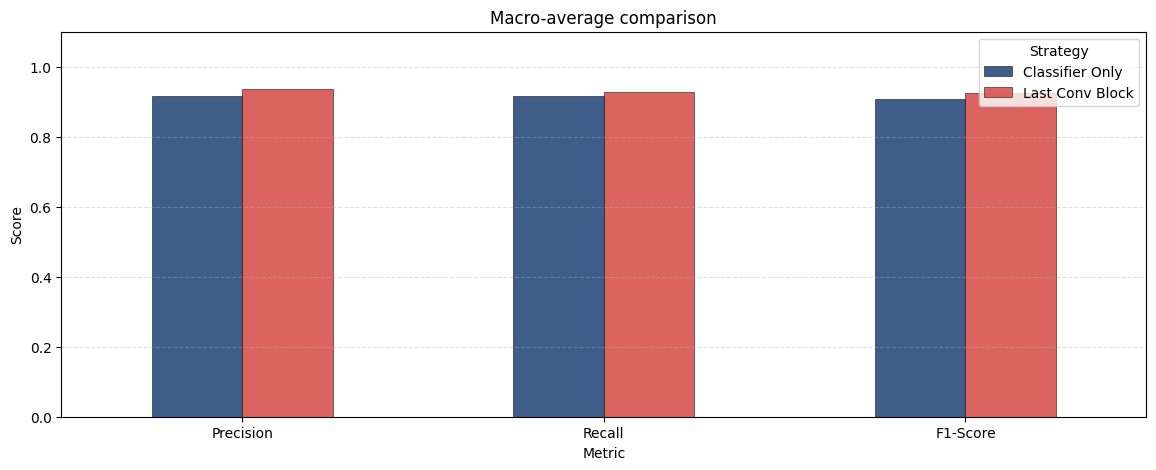

In [36]:
import matplotlib.pyplot as plt

macro = {
    'Metric': ['Precision', 'Recall', 'F1-Score'],
    'Classifier Only': [
        classifier_results['precision'].mean(),
        classifier_results['recall'].mean(),
        classifier_results['f1-score'].mean(),
    ],
    'Last Conv Block': [
        last_block_results['precision'].mean(),
        last_block_results['recall'].mean(),
        last_block_results['f1-score'].mean(),
    ],
}
macro_df = pd.DataFrame(macro).set_index('Metric')

merged = classifier_results[['class', 'f1-score']].merge(
    last_block_results[['class', 'f1-score']],
    on='class',
    suffixes=('_classifier', '_lastblock'),
)
f1_delta = merged['f1-score_lastblock'] - merged['f1-score_classifier']

fig, axes = plt.subplots(1, figsize=(14, 5))

macro_df.plot(
    kind='bar',
    ax=axes,
    color=['#2A4B7C', '#D9534F'],
    alpha=0.9,
    edgecolor='black',
    linewidth=0.4,
)
axes.set_title('Macro-average comparison')
axes.set_ylabel('Score')
axes.set_ylim(0, 1.1)
axes.legend(title='Strategy')
axes.grid(axis='y', linestyle='--', alpha=0.4)
axes.tick_params(axis='x', labelrotation=0)
